In [ ]:
import os, sys
import numpy as np
import sys
sys.path.insert(0, "/Users/ivanzait/Documents/Documents_LM4500/Codes/analysator")
import pytools as pt
import matplotlib.pyplot as plt

# sys.path.insert(0, os.path.join(os.path.dirname(__file__), '..'))
# sys.path.insert(0, os.path.join(os.path.dirname(__file__), '..', 'data_processing'))
sys.path.insert(0, "/Users/ivanzait/Documents/Documents_LM4500/Codes/FAISER_corrector/faiser/data_processing")
import vdf_tools as vt
#from adaptive_hermite import cubic_transform
from vdf_tools import velocity_axis, hermite_basis, _log_delta, _compute_level, _level_power

#PLOTDIR = os.path.join(os.path.dirname(__file__), '..', 'ml_corrector', 'plots')

def adaptive_transform(vdf, vlim, vlen, vth, u,
                       max_order=14,
                       sp_th=1e-15,
                       tolerance=0.15,
                       ):
    
    dv   = 2.0 * vlim / vlen
    v_ax = velocity_axis(vlim, vlen, dv)

    # Precompute all basis functions
    Hx = hermite_basis(v_ax, max_order , vth, u[0])
    Hy = hermite_basis(v_ax, max_order , vth, u[1])
    Hz = hermite_basis(v_ax, max_order , vth, u[2])

    coeffs        = {}
    log_delta = {}
    log_delta[0]     = _log_delta(vdf, np.zeros_like(vdf), sp_th)
    current_power = np.zeros((vlen, vlen, vlen), dtype=np.float64)

    def _process_level(s):
        nonlocal log_delta, current_power
        new_c, _lp = _compute_level(vdf, s, Hx, Hy, Hz, dv)
        coeffs.update(new_c)
        current_power += _level_power(new_c, Hx, Hy, Hz, dv, vlen)
        log_delta[s] = _log_delta(vdf, current_power, sp_th)
        return log_delta[s] < tolerance if s> 2 else False

    s_stop = max_order - 1
    for s in range(max_order):
        if _process_level(s):
            return coeffs, s+1, log_delta

    return coeffs, max_order, log_delta


def reconstruct_vdf_adaptive(coeffs, vlim, vlen, order, vth, u ):
    """reconstruction from a coefficient dict // for adaptive algo """
    dv   = 2.0 * vlim / vlen
    v_ax = vt.velocity_axis(vlim, vlen, dv)
    Hx   = vt.hermite_basis(v_ax, order, vth, u[0])
    Hy   = vt.hermite_basis(v_ax, order, vth, u[1])
    Hz   = vt.hermite_basis(v_ax, order, vth, u[2])
    rec = np.zeros((vlen, vlen, vlen), dtype=np.float64)
    for (l, m, n), c in coeffs.items():
        rec += c * np.einsum('x,y,z->zyx', Hx[n], Hy[m], Hz[l])
    return rec




In [ ]:
BULK_FILE   = "/Users/ivanzait/Downloads/bulk.0000055.vlsv"
CELL_COORDS = [1e+6, 0, 1e+6]   # None = center of box; nearest cell with a VDF is used
ORDER       = 26          # indices l,m,n run 0..ORDER-1 for both transforms
SP_TH       = 1e-15

reader = pt.vlsvfile.VlsvReader(BULK_FILE)

vlim, vlen, dv = vt.get_vdf_parameters(reader)
cellid = vt.get_nearest_vdf_cellid(reader, coords=CELL_COORDS)
cube = vt.build_cube(cellid, reader, vlim, vlen, dv)
mask = cube < SP_TH
u    = vt.get_drift_velocity_cube(cube, vlim, vlen)
vth  = vt.get_thermal_velocity_cube(cube, vlim, vlen, u)

spectra, s_stop, delta = adaptive_transform(cube, vlim, vlen, vth, u, max_order=ORDER, tolerance=0.4)
print('stopped at order:', s_stop)
####coeffs_cubic, eps_cubic, _ = cubic_transform(cube, vlim, vlen, vth, u, ORDER)

vdf_rec = reconstruct_vdf_adaptive(spectra, vlim, vlen, ORDER, vth, u )
vdf_rec[mask] = 0.0
eps_rel = float(np.linalg.norm(cube - vdf_rec) / np.linalg.norm(cube))

print(f"\n{'':12s}  {'n_coeffs':>8}  {'eps_rel':>8}  ")
print( f"{'tetrahedral':12s}  {len(spectra):8d}  {eps_rel:8.5f}" )


INFO: Found population proton
INFO: Getting offsets for population proton


ns: 100 100 100
dvs: 30000.0 30000.0 30000.0
mins: -1500000.0 -1500000.0 -1500000.0
stopped at order: 4

              n_coeffs   eps_rel  
tetrahedral         20   0.02258


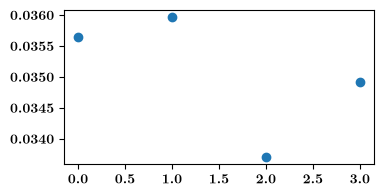

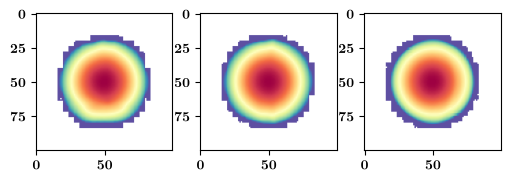

In [ ]:

### Parseval delta vs N harmonics
fig = plt.figure(figsize=[4,2])
ax = fig.subplots(1,1)
ax.scatter(list(delta.keys()), list(delta.values()) )

    
from matplotlib.colors import LogNorm
### VDF
fig = plt.figure(figsize=[6,8])
axs = fig.subplots(1,3)
for i, ax in enumerate(axs):
    ax.imshow(np.sum(cube, axis=i), cmap='Spectral_r', norm=LogNorm(vmin=1e-15, vmax=np.sum(cube, axis=i).max())) 

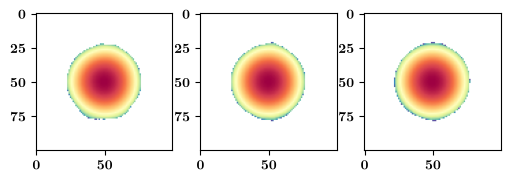

In [92]:
### tool for reconstruction of the vdf from cropped spectra

def crop_spectra_tetra(spectra, crop_order):
    """Tetrahedral crop: keep l+m+n < crop_order. Shape unchanged, the rest zeroed."""
    l, m, n = np.indices(spectra.shape)
    return np.where(l + m + n < crop_order, spectra, 0.0)        

def coeffs_into_cube(coeffs, hermite_order):
    """Dense (hermite_order, hermite_order, hermite_order) array; indices l,m,n run 0..hermite_order-1."""
    h_cube = np.zeros([hermite_order, hermite_order, hermite_order])
    for k, v in coeffs.items():        
        h_cube[k] = v
    return h_cube

        
order_used = s_stop                      # 4, the count returned by adaptive_transform
crop_order = 26

spectra_filled  = coeffs_into_cube(spectra, order_used)         # 4x4x4, holds everything
cropped = {k: v for k, v in spectra.items() if sum(k) < crop_order}
vdf_rec = reconstruct_vdf_adaptive(cropped, vlim, vlen, order_used, vth, u)
vdf_rec[mask] = 0

### VDF
fig = plt.figure(figsize=[6,8])
axs = fig.subplots(1,3)
for i, ax in enumerate(axs):
    ax.imshow(np.sum(vdf_rec, axis=i), cmap='Spectral_r', norm=LogNorm(vmin=1e-15, vmax=np.sum(cube, axis=i).max())) 

